# Pandas Foundations — House Prices Dataset
## Exploratory Data Analysis (EDA) for Regression

**Dataset:** Ames Housing (2,930 houses, 80 features)  
**Goal:** Predict `SalePrice` — understand the data before modeling

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/AmesHousing.csv")
print("Shape: ", df.shape)
print("Memory Usage: ", df.memory_usage(deep=True).sum() / 1024**2, "MB")

Shape:  (2930, 82)
Memory Usage:  6.915376663208008 MB


In [7]:
# Data types
df.dtypes.value_counts()

str        43
int64      28
float64    11
Name: count, dtype: int64

In [13]:
# Target Variable
print("Sales Stata")
print(df["SalePrice"].describe().round(2))
print(f"Min: {df["SalePrice"].min()}")
print(f"Max: {df["SalePrice"].max()}")
print(f"Median: {df["SalePrice"].median()}")

Sales Stata
count      2930.00
mean     180796.06
std       79886.69
min       12789.00
25%      129500.00
50%      160000.00
75%      213500.00
max      755000.00
Name: SalePrice, dtype: float64
Min: 12789
Max: 755000
Median: 160000.0


## Missing Value Analysis

In [39]:
# count + percentage of missing values per column
missing = df.isnull().count()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
}).query("missing_count > 0").sort_values("missing_pct", ascending=False)

print("Columns with missing data: ", len(missing_df))
missing_df.head(20)

Columns with missing data:  82


,missing_count,missing_pct
Order,2930,100.0
PID,2930,100.0
MS SubClass,2930,100.0
MS Zoning,2930,100.0
Lot Frontage,2930,100.0
Lot Area,2930,100.0
Street,2930,100.0
Alley,2930,100.0
Lot Shape,2930,100.0
Land Contour,2930,100.0


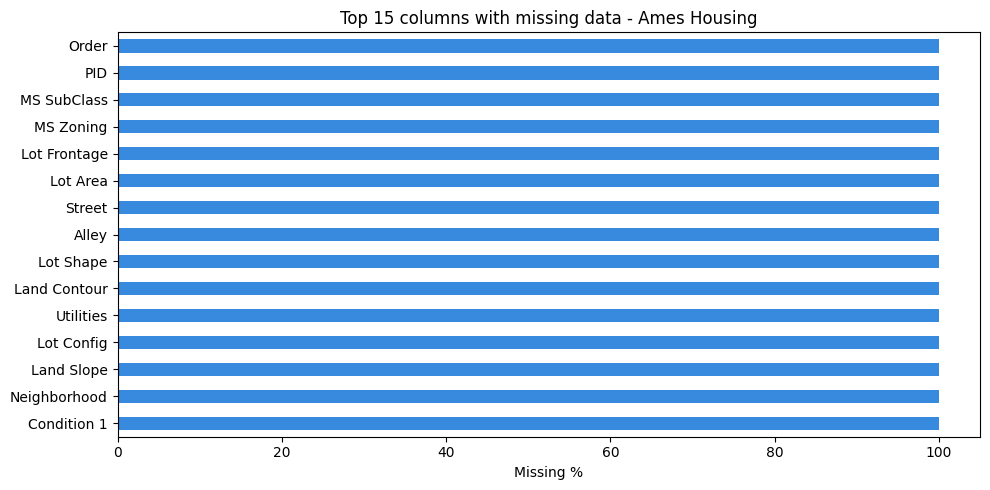

Saved to artifacts/missing_values.png


In [43]:
# Visualize the missing data
fig, ax = plt.subplots(figsize=(10, 5))
missing_df["missing_pct"].head(15).plot(kind="barh", ax=ax, color="#378ADD")
ax.set_xlabel("Missing %")
ax.set_title("Top 15 columns with missing data - Ames Housing")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../artifacts/missing_values.png", dpi=150)
plt.show()
print("Saved to artifacts/missing_values.png")

## DataFrame Selection & Filtering

In [44]:
# select specific columns
cols = ["Gr Liv Area", "Bedroom AbvGr", "Year Built", "Overall Qual", "SalePrice"]
subs = df[cols].copy()
subs.head()

,Gr Liv Area,Bedroom AbvGr,Year Built,Overall Qual,SalePrice
0,1656,3,1960,6,215000
1,896,2,1961,5,105000
2,1329,3,1958,6,172000
3,2110,3,1968,7,244000
4,1629,3,1997,5,189900


In [48]:
# Filter rows — boolean indexing (same concept as NumPy masking)
expensive = df[df["SalePrice"] > 300_000]
print("Prices over $300k:", len(expensive))

# Multi-condition filter
high_quality_large = df[
    (df["Overall Qual"] >= 8) &
    (df["Gr Liv Area"] > 2000)
]
print("High Quality + Large:", len(high_quality_large))
print("Average Price:", high_quality_large["SalePrice"].mean().round(2))

Prices over $300k: 230
High Quality + Large: 191
Average Price: 360472.79


In [50]:
# .loc vs .iloc — the two indexers to know
# .loc → label-based (column names, index labels)
# .iloc → position-based (row/col numbers)

print("loc - first 3 rows, specific columns:")
print(df.loc[:2, ["Gr Liv Area", "SalePrice"]])

print("\niloc - rows 5-8, first 4 columns:")
print(df.iloc[5:9, :4])

loc - first 3 rows, specific columns:
   Gr Liv Area  SalePrice
0         1656     215000
1          896     105000
2         1329     172000

iloc - rows 5-8, first 4 columns:
   Order        PID  MS SubClass MS Zoning
5      6  527105030           60        RL
6      7  527127150          120        RL
7      8  527145080          120        RL
8      9  527146030          120        RL


## GroupBy - Finding Price Drivers

In [52]:
# Average sale price by overall quality rating (1-10)
price_by_quality = (
    df.groupby("Overall Qual")["SalePrice"]
    .agg(["mean", "median", "count"])
    .round(0)
    .rename(columns={"mean": "avg_price", "median": "median_price", "cont": "num_houses"})
)

print(price_by_quality)

              avg_price  median_price  count
Overall Qual                                
1               48725.0       50150.0      4
2               52325.0       57625.0     13
3               83186.0       81200.0     40
4              106485.0      105000.0    226
5              134753.0      133000.0    825
6              162130.0      159500.0    732
7              205026.0      200000.0    602
8              270914.0      264530.0    350
9              368337.0      360000.0    107
10             450217.0      451950.0     31


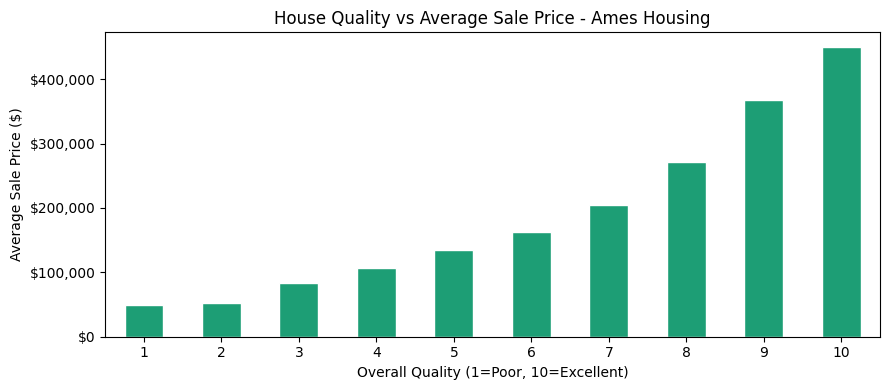

In [54]:
# Visualise - quality vs price
fig, ax = plt.subplots(figsize=(9,4))
price_by_quality["avg_price"].plot(kind="bar", ax=ax, color="#1D9E75", edgecolor="white")
ax.set_xlabel("Overall Quality (1=Poor, 10=Excellent)")
ax.set_ylabel("Average Sale Price ($)")
ax.set_title("House Quality vs Average Sale Price - Ames Housing")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../artifacts/quality_vs_price.png", dpi=150)
plt.show()